# Notebook 05 — Question Pattern & Assessment Pressure Analysis

## Purpose
Describe historical assessment **exposure** in mapped 2023–2025 NSC Mathematics exam subquestions.

## Exposure means
Frequency × mark weight

## This notebook does NOT
- measure difficulty
- rank intervention priority
- predict next exam questions
- infer misconceptions

Difficulty → Notebook 06  
Priority → Notebook 07

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
MAPPED_DIR = PROCESSED / "mapped"
OUT_DIR = PROCESSED / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Correct frozen input from Notebook 04
INPUT = MAPPED_DIR / "question_topic_map_exams_v1.csv"

print("Input exists:", INPUT.exists())
print("Output dir:", OUT_DIR)

Input exists: True
Output dir: c:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\analysis


In [2]:
df = pd.read_csv(INPUT)
print("Loaded rows:", len(df))
print("Columns:", df.columns.tolist())

analysis_df = df[df["topic"].astype(str).str.strip().ne("Unmapped")].copy()

# Derive year/paper from document_id when missing
if "year" not in analysis_df.columns or analysis_df["year"].isna().all():
    analysis_df["year"] = analysis_df["document_id"].astype(str).str.extract(r"(20\d{2})")

if "paper" not in analysis_df.columns or analysis_df["paper"].isna().all():
    analysis_df["paper"] = analysis_df["document_id"].astype(str).str.extract(r"[_\-](p[12])[_\-]", expand=False)

analysis_df["year"] = pd.to_numeric(analysis_df["year"], errors="coerce").astype("Int64")
analysis_df["paper"] = analysis_df["paper"].astype(str).str.upper().str.replace("P", "P", regex=False)
analysis_df["paper"] = analysis_df["paper"].str.replace(r".*(P[12]).*", r"\1", regex=True)
analysis_df["marks"] = pd.to_numeric(analysis_df.get("marks"), errors="coerce")
analysis_df["topic"] = analysis_df["topic"].astype(str).str.strip()

print("Analysis rows:", len(analysis_df))
print(analysis_df.groupby(["year", "paper"], dropna=False).size())
print("Marks coverage:", f"{analysis_df['marks'].notna().mean():.1%}")

Loaded rows: 261
Columns: ['document_id', 'year', 'paper', 'document_type', 'source_text_file', 'extraction_quality', 'question_number', 'subquestion', 'marks', 'marks_all_found', 'question_text', 'question_char_count', 'segment_index', 'segmentation_status', 'question_id', 'topic', 'subtopic', 'mapping_method', 'rule_id', 'mapping_confidence', 'taxonomy_version']
Analysis rows: 261
year  paper
2021  NaN       1
2023  P1       49
      P2       46
2024  P1       37
      P2       41
2025  P1       44
      P2       43
dtype: int64
Marks coverage: 57.5%


In [3]:
assert len(analysis_df) > 0
assert analysis_df["topic"].ne("Unmapped").all()
print("Integrity checks passed")
print("Topics:\n", analysis_df["topic"].value_counts())

Integrity checks passed
Topics:
 topic
Calculus                       45
Functions & Graphs             39
Trigonometry                   38
Analytical Geometry            33
Statistics                     28
Algebra & Equations            23
Number Patterns & Sequences    17
Euclidean Geometry             17
Probability                    16
Finance                         5
Name: count, dtype: int64


,topic,subquestion_count,frequency_share_pct
2,Calculus,45,17.24
5,Functions & Graphs,39,14.94
9,Trigonometry,38,14.56
1,Analytical Geometry,33,12.64
8,Statistics,28,10.73
0,Algebra & Equations,23,8.81
6,Number Patterns & Sequences,17,6.51
3,Euclidean Geometry,17,6.51
7,Probability,16,6.13
4,Finance,5,1.92


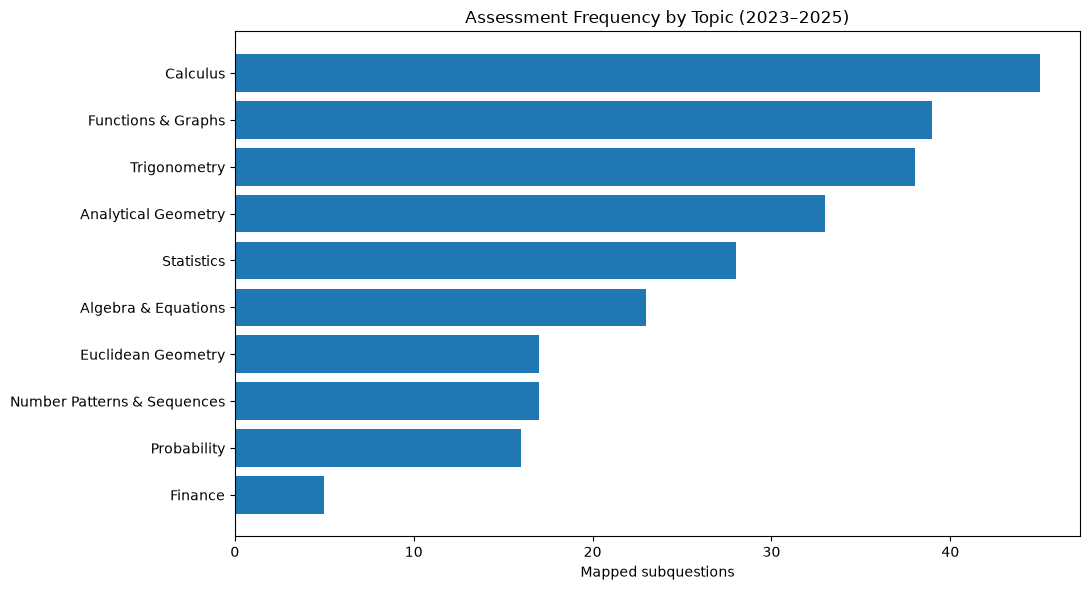

In [4]:
topic_frequency = (
    analysis_df.groupby("topic")
    .size()
    .reset_index(name="subquestion_count")
    .sort_values("subquestion_count", ascending=False)
)
topic_frequency["frequency_share_pct"] = (
    topic_frequency["subquestion_count"] / topic_frequency["subquestion_count"].sum() * 100
).round(2)

display(topic_frequency)

plt.figure(figsize=(11, 6))
plot_df = topic_frequency.sort_values("subquestion_count")
plt.barh(plot_df["topic"], plot_df["subquestion_count"])
plt.xlabel("Mapped subquestions")
plt.title("Assessment Frequency by Topic (2023–2025)")
plt.tight_layout()
plt.show()

In [5]:
marks_df = analysis_df.dropna(subset=["marks"]).copy()
print("Rows with marks:", len(marks_df))

topic_marks = (
    marks_df.groupby("topic")
    .agg(
        subquestion_count=("topic", "count"),
        total_marks=("marks", "sum"),
        mean_marks=("marks", "mean"),
        median_marks=("marks", "median"),
    )
    .reset_index()
)
topic_marks["mark_share_pct"] = (
    topic_marks["total_marks"] / topic_marks["total_marks"].sum() * 100
).round(2)
topic_marks = topic_marks.sort_values("total_marks", ascending=False)
display(topic_marks)

Rows with marks: 150


,topic,subquestion_count,total_marks,mean_marks,median_marks,mark_share_pct
2,Calculus,33,248.0,7.515152,6.0,26.47
9,Trigonometry,21,162.0,7.714286,5.0,17.29
5,Functions & Graphs,26,130.0,5.000000,3.0,13.87
1,Analytical Geometry,23,114.0,4.956522,3.0,12.17
0,Algebra & Equations,14,74.0,5.285714,4.0,7.90
3,Euclidean Geometry,11,67.0,6.090909,5.0,7.15
6,Number Patterns & Sequences,6,63.0,10.500000,10.0,6.72
8,Statistics,11,51.0,4.636364,3.0,5.44
4,Finance,2,19.0,9.500000,9.5,2.03
7,Probability,3,9.0,3.000000,3.0,0.96


,topic,subquestion_count,frequency_share_pct,total_marks,mark_share_pct,mean_marks,count_minus_mark_pct,assessment_pressure_score
0,Calculus,45,17.24,248.0,26.47,7.515152,-9.23,21.85
2,Trigonometry,38,14.56,162.0,17.29,7.714286,-2.73,15.92
1,Functions & Graphs,39,14.94,130.0,13.87,5.000000,1.07,14.40
3,Analytical Geometry,33,12.64,114.0,12.17,4.956522,0.47,12.40
5,Algebra & Equations,23,8.81,74.0,7.90,5.285714,0.91,8.36
4,Statistics,28,10.73,51.0,5.44,4.636364,5.29,8.09
7,Euclidean Geometry,17,6.51,67.0,7.15,6.090909,-0.64,6.83
6,Number Patterns & Sequences,17,6.51,63.0,6.72,10.500000,-0.21,6.62
8,Probability,16,6.13,9.0,0.96,3.000000,5.17,3.54
9,Finance,5,1.92,19.0,2.03,9.500000,-0.11,1.98


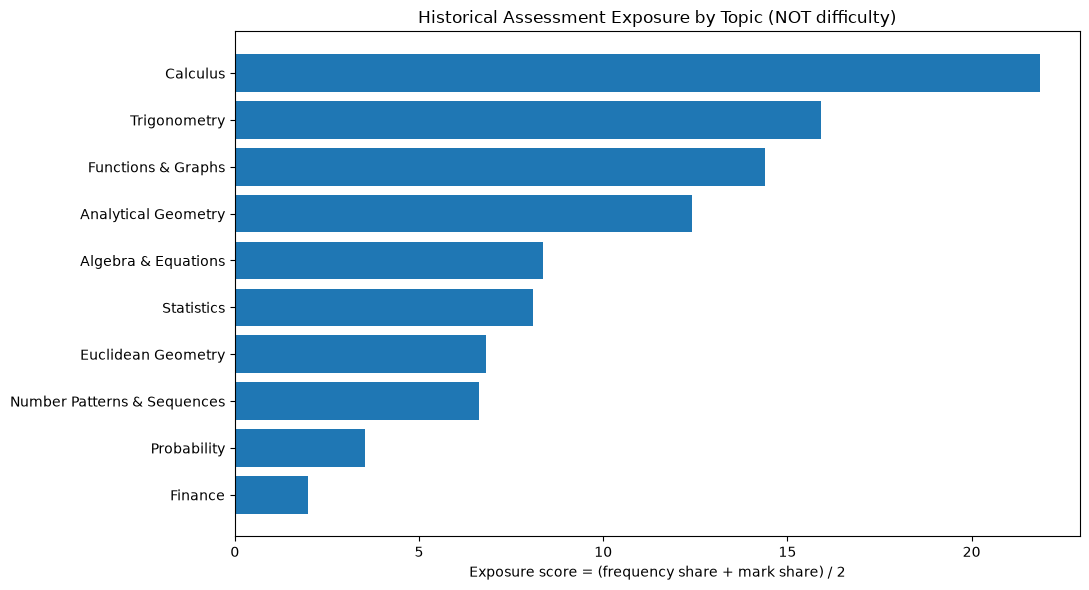

In [6]:
topic_pressure = topic_frequency.merge(
    topic_marks[["topic", "total_marks", "mark_share_pct", "mean_marks"]],
    on="topic",
    how="left",
)
topic_pressure["count_minus_mark_pct"] = (
    topic_pressure["frequency_share_pct"] - topic_pressure["mark_share_pct"]
).round(2)

# Exposure score = average of frequency share and mark share
topic_pressure["assessment_pressure_score"] = (
    (topic_pressure["frequency_share_pct"].fillna(0) + topic_pressure["mark_share_pct"].fillna(0)) / 2
).round(2)

topic_pressure = topic_pressure.sort_values("assessment_pressure_score", ascending=False)
display(topic_pressure)

plt.figure(figsize=(11, 6))
p = topic_pressure.sort_values("assessment_pressure_score")
plt.barh(p["topic"], p["assessment_pressure_score"])
plt.xlabel("Exposure score = (frequency share + mark share) / 2")
plt.title("Historical Assessment Exposure by Topic (NOT difficulty)")
plt.tight_layout()
plt.show()

In [10]:
year_topic = (
    analysis_df.groupby(["year", "topic"])
    .size()
    .reset_index(name="subquestion_count")
)
year_topic["year_total"] = year_topic.groupby("year")["subquestion_count"].transform("sum")
year_topic["share_pct"] = (year_topic["subquestion_count"] / year_topic["year_total"] * 100).round(2)

year_matrix = pd.pivot_table(
    analysis_df, index="topic", columns="year",
    values="document_id", aggfunc="count", fill_value=0
)
display(year_matrix)

year_share = (year_matrix / year_matrix.sum(axis=0) * 100).round(2)
display(year_share)

year,2021,2023,2024,2025
topic,,,,
Algebra & Equations,0,16,6,1
Analytical Geometry,0,14,9,10
Calculus,0,14,15,16
Euclidean Geometry,1,7,6,3
Finance,0,0,3,2
Functions & Graphs,0,15,6,18
Number Patterns & Sequences,0,1,8,8
Probability,0,8,4,4
Statistics,0,7,11,10


year,2021,2023,2024,2025
topic,,,,
Algebra & Equations,0.0,16.84,7.69,1.15
Analytical Geometry,0.0,14.74,11.54,11.49
Calculus,0.0,14.74,19.23,18.39
Euclidean Geometry,100.0,7.37,7.69,3.45
Finance,0.0,0.00,3.85,2.30
Functions & Graphs,0.0,15.79,7.69,20.69
Number Patterns & Sequences,0.0,1.05,10.26,9.20
Probability,0.0,8.42,5.13,4.60
Statistics,0.0,7.37,14.10,11.49


In [11]:
paper_topic = (
    analysis_df.groupby(["paper", "topic"])
    .size()
    .reset_index(name="subquestion_count")
)
paper_topic["paper_total"] = paper_topic.groupby("paper")["subquestion_count"].transform("sum")
paper_topic["share_pct"] = (paper_topic["subquestion_count"] / paper_topic["paper_total"] * 100).round(2)
display(paper_topic.sort_values(["paper", "subquestion_count"], ascending=[True, False]))

paper_matrix = pd.pivot_table(
    analysis_df, index="topic", columns="paper",
    values="document_id", aggfunc="count", fill_value=0
)
display(paper_matrix)

,paper,topic,subquestion_count,paper_total,share_pct
2,P1,Calculus,33,130,25.38
4,P1,Functions & Graphs,27,130,20.77
0,P1,Algebra & Equations,17,130,13.08
5,P1,Number Patterns & Sequences,17,130,13.08
6,P1,Probability,16,130,12.31
7,P1,Trigonometry,11,130,8.46
3,P1,Finance,5,130,3.85
1,P1,Analytical Geometry,4,130,3.08
9,P2,Analytical Geometry,29,130,22.31
13,P2,Statistics,28,130,21.54


paper,P1,P2
topic,,
Algebra & Equations,17,6
Analytical Geometry,4,29
Calculus,33,12
Euclidean Geometry,0,16
Finance,5,0
Functions & Graphs,27,12
Number Patterns & Sequences,17,0
Probability,16,0
Statistics,0,28


In [12]:
if "command_verb" in analysis_df.columns:
    cmd = (
        analysis_df.dropna(subset=["command_verb"])
        .assign(command_verb=lambda x: x["command_verb"].astype(str).str.strip().str.lower())
        .groupby("command_verb")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    cmd["share_pct"] = (cmd["count"] / cmd["count"].sum() * 100).round(2)
    display(cmd.head(20))
    cmd.to_csv(OUT_DIR / "command_verb_profile_2023_2025.csv", index=False)
else:
    print("No command_verb column in frozen map — skip verb analysis in v1")

No command_verb column in frozen map — skip verb analysis in v1


In [13]:
topic_frequency.to_csv(OUT_DIR / "topic_frequency_2023_2025.csv", index=False)
topic_marks.to_csv(OUT_DIR / "topic_mark_allocation_2023_2025.csv", index=False)
topic_pressure.to_csv(OUT_DIR / "assessment_pressure_2023_2025.csv", index=False)
paper_topic.to_csv(OUT_DIR / "paper_topic_profile_2023_2025.csv", index=False)
year_topic.to_csv(OUT_DIR / "year_topic_profile_2023_2025.csv", index=False)
year_matrix.to_csv(OUT_DIR / "year_topic_matrix_2023_2025.csv")
year_share.to_csv(OUT_DIR / "year_topic_share_2023_2025.csv")

print("Saved outputs to:", OUT_DIR)
for p in sorted(OUT_DIR.glob("*.csv")):
    print(" -", p.name)

Saved outputs to: c:\Users\Administrator\Desktop\Matric-Maths-Exam-Intelligence\data\processed\analysis
 - assessment_pressure_2023_2025.csv
 - paper_topic_profile_2023_2025.csv
 - topic_frequency_2023_2025.csv
 - topic_mark_allocation_2023_2025.csv
 - year_topic_matrix_2023_2025.csv
 - year_topic_profile_2023_2025.csv
 - year_topic_share_2023_2025.csv


In [14]:
print("=" * 60)
print("NOTEBOOK 05 COMPLETE")
print("=" * 60)
print("Rows analysed:", len(analysis_df))
print("Years:", sorted(analysis_df["year"].dropna().unique().tolist()))
print("Papers:", sorted(analysis_df["paper"].dropna().unique().tolist()))
print("Topics:", analysis_df["topic"].nunique())
print("Marks coverage:", f"{analysis_df['marks'].notna().mean():.1%}")
print("Top exposure topic:", topic_pressure.iloc[0]["topic"] if len(topic_pressure) else None)
print("=" * 60)
print("Reminder: exposure ≠ difficulty ≠ priority")

NOTEBOOK 05 COMPLETE
Rows analysed: 261
Years: [2021, 2023, 2024, 2025]
Papers: ['P1', 'P2']
Topics: 10
Marks coverage: 57.5%
Top exposure topic: Calculus
Reminder: exposure ≠ difficulty ≠ priority


In [15]:
topic_pressure = topic_frequency.merge(
    topic_marks[["topic", "total_marks", "mark_share_pct", "mean_marks"]],
    on="topic",
    how="left"
)
topic_pressure["assessment_pressure_score"] = (
    (topic_pressure["frequency_share_pct"].fillna(0) + topic_pressure["mark_share_pct"].fillna(0)) / 2
).round(2)
topic_pressure = topic_pressure.sort_values("assessment_pressure_score", ascending=False)
display(topic_pressure)

,topic,subquestion_count,frequency_share_pct,total_marks,mark_share_pct,mean_marks,assessment_pressure_score
0,Calculus,45,17.24,248.0,26.47,7.515152,21.85
2,Trigonometry,38,14.56,162.0,17.29,7.714286,15.92
1,Functions & Graphs,39,14.94,130.0,13.87,5.000000,14.40
3,Analytical Geometry,33,12.64,114.0,12.17,4.956522,12.40
5,Algebra & Equations,23,8.81,74.0,7.90,5.285714,8.36
4,Statistics,28,10.73,51.0,5.44,4.636364,8.09
7,Euclidean Geometry,17,6.51,67.0,7.15,6.090909,6.83
6,Number Patterns & Sequences,17,6.51,63.0,6.72,10.500000,6.62
8,Probability,16,6.13,9.0,0.96,3.000000,3.54
9,Finance,5,1.92,19.0,2.03,9.500000,1.98


In [16]:
print("NOTEBOOK 05 COMPLETE")
print("Years used:", sorted(analysis_df["year"].dropna().unique().tolist()))
print("Rows:", len(analysis_df))
print("Top exposure topic:", topic_pressure.iloc[0]["topic"])
print("Exposure ≠ difficulty ≠ priority")

NOTEBOOK 05 COMPLETE
Years used: [2021, 2023, 2024, 2025]
Rows: 261
Top exposure topic: Calculus
Exposure ≠ difficulty ≠ priority
